# Assignment 09-Feature Importance Visualization

### Domain: Powertrain Efficiency, Vehicle Fuel Consumption Attribution & Explainable AI (XAI)
---

## Aim

To visualize and interpret the importance of automotive features affecting vehicle fuel consumption using tree-based machine learning models and Explainable AI techniques.

The experiment compares:

- Mean Decrease in Impurity (MDI)
- Permutation Feature Importance (PFI)
- Mutual Information (MI)
- Partial Dependence Plots (PDP)
- Noise Immunity Testing

The objective is to understand which physical vehicle attributes contribute most strongly to fuel-consumption predictions and to verify that an intentionally added random noise feature receives very low importance.

In [1]:
# ============================================================
# CELL 1 — Import Required Libraries
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.inspection import (
    permutation_importance,
    PartialDependenceDisplay
)

from sklearn.feature_selection import (
    mutual_info_regression
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# CELL 2 — Set Random Seed
# ============================================================

SEED = 42

np.random.seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [3]:
# ============================================================
# CELL 3 — Generate Synthetic Automotive Dataset
# ============================================================

n = 700

# Physical vehicle attributes
engine_displacement_L = np.random.uniform(
    1.0, 5.0, n
)

vehicle_weight_kg = (
    900
    + engine_displacement_L * 320
    + np.random.normal(0, 100, n)
)

horsepower = (
    55
    + engine_displacement_L * 42
    + np.random.normal(0, 18, n)
)

aerodynamic_drag_coefficient = np.random.uniform(
    0.22, 0.42, n
)

frontal_area_m2 = np.random.uniform(
    1.8, 3.2, n
)

tire_rolling_resistance = np.random.uniform(
    0.008, 0.015, n
)

transmission_efficiency = np.random.uniform(
    0.78, 0.96, n
)

# Completely unrelated random feature
random_noise = np.random.normal(
    0, 1, n
)

# ------------------------------------------------------------
# Synthetic fuel consumption relationship
# Lower value = better fuel economy
# ------------------------------------------------------------

fuel_consumption_L_per_100km = (
    3.0
    + 0.85 * engine_displacement_L
    + 0.0028 * vehicle_weight_kg
    + 0.008 * horsepower
    + 9.0 * aerodynamic_drag_coefficient
    + 1.8 * frontal_area_m2
    + 220 * tire_rolling_resistance
    - 4.0 * transmission_efficiency
    + 0.25 * np.sin(engine_displacement_L * 2)
    + np.random.normal(0, 0.6, n)
)

fuel_consumption_L_per_100km = np.clip(
    fuel_consumption_L_per_100km,
    3,
    None
)

print("Synthetic automotive dataset generated.")
print("Number of records:", n)

Synthetic automotive dataset generated.
Number of records: 700


In [4]:
# ============================================================
# CELL 4 — Create Automotive DataFrame
# ============================================================

auto_df = pd.DataFrame({

    "engine_displacement_L":
        engine_displacement_L,

    "vehicle_weight_kg":
        vehicle_weight_kg,

    "horsepower":
        horsepower,

    "aerodynamic_drag_coefficient":
        aerodynamic_drag_coefficient,

    "frontal_area_m2":
        frontal_area_m2,

    "tire_rolling_resistance":
        tire_rolling_resistance,

    "transmission_efficiency":
        transmission_efficiency,

    "random_noise":
        random_noise,

    "fuel_consumption_L_per_100km":
        fuel_consumption_L_per_100km
})

display(
    auto_df.head()
)

,engine_displacement_L,vehicle_weight_kg,horsepower,aerodynamic_drag_coefficient,frontal_area_m2,tire_rolling_resistance,transmission_efficiency,random_noise,fuel_consumption_L_per_100km
0,2.498160,1634.227741,145.456598,0.315109,2.870217,0.012607,0.804863,-0.432774,18.133903
1,4.802857,2441.654179,286.224106,0.328605,2.373539,0.008491,0.934640,0.793818,20.512286
2,3.927976,2070.910909,250.173597,0.265550,2.717243,0.010767,0.870010,-0.297376,20.672913
3,3.394634,1947.827305,187.610037,0.412806,2.164331,0.009272,0.901481,-0.246383,18.984690
4,1.624075,1520.333141,133.452827,0.401891,2.023289,0.009098,0.823032,0.986377,15.734894


In [5]:
# ============================================================
# CELL 5 — Dataset Inspection
# ============================================================

print("Dataset shape:")
print(auto_df.shape)

print("\nColumn names:")
print(auto_df.columns.tolist())

print("\nData types:")
print(auto_df.dtypes)

print("\nMissing values:")
print(auto_df.isnull().sum())

Dataset shape:
(700, 9)

Column names:
['engine_displacement_L', 'vehicle_weight_kg', 'horsepower', 'aerodynamic_drag_coefficient', 'frontal_area_m2', 'tire_rolling_resistance', 'transmission_efficiency', 'random_noise', 'fuel_consumption_L_per_100km']

Data types:
engine_displacement_L           float64
vehicle_weight_kg               float64
horsepower                      float64
aerodynamic_drag_coefficient    float64
frontal_area_m2                 float64
tire_rolling_resistance         float64
transmission_efficiency         float64
random_noise                    float64
fuel_consumption_L_per_100km    float64
dtype: object

Missing values:
engine_displacement_L           0
vehicle_weight_kg               0
horsepower                      0
aerodynamic_drag_coefficient    0
frontal_area_m2                 0
tire_rolling_resistance         0
transmission_efficiency         0
random_noise                    0
fuel_consumption_L_per_100km    0
dtype: int64


In [6]:
# ============================================================
# CELL 6 — Descriptive Statistics
# ============================================================

display(
    auto_df.describe().round(3)
)

,engine_displacement_L,vehicle_weight_kg,horsepower,aerodynamic_drag_coefficient,frontal_area_m2,tire_rolling_resistance,transmission_efficiency,random_noise,fuel_consumption_L_per_100km
count,700.000,700.000,700.000,700.000,700.000,700.000,700.000,700.000,700.000
mean,2.971,1858.763,180.555,0.321,2.490,0.011,0.870,-0.070,18.581
std,1.180,390.901,52.597,0.059,0.399,0.002,0.052,0.993,2.804
min,1.020,999.184,72.772,0.220,1.801,0.008,0.780,-3.177,12.231
25%,1.950,1531.057,135.932,0.273,2.137,0.010,0.825,-0.702,16.227
50%,3.011,1853.540,182.430,0.320,2.483,0.011,0.867,-0.018,18.463
75%,4.003,2184.205,223.265,0.372,2.848,0.013,0.916,0.646,20.858
max,4.999,2697.720,303.512,0.420,3.199,0.015,0.959,2.755,24.378


In [7]:
# ============================================================
# CELL 7 — Feature Correlation with Target
# ============================================================

target_column = (
    "fuel_consumption_L_per_100km"
)

correlation = (
    auto_df
    .corr(numeric_only=True)[target_column]
    .sort_values(
        ascending=False
    )
)

print(
    "Correlation with fuel consumption:"
)

display(
    correlation.to_frame(
        name="Correlation"
    )
)

Correlation with fuel consumption:


,Correlation
fuel_consumption_L_per_100km,1.000000
engine_displacement_L,0.897817
vehicle_weight_kg,0.890916
horsepower,0.852679
frontal_area_m2,0.319453
aerodynamic_drag_coefficient,0.199438
tire_rolling_resistance,0.130715
transmission_efficiency,-0.076516
random_noise,-0.076821


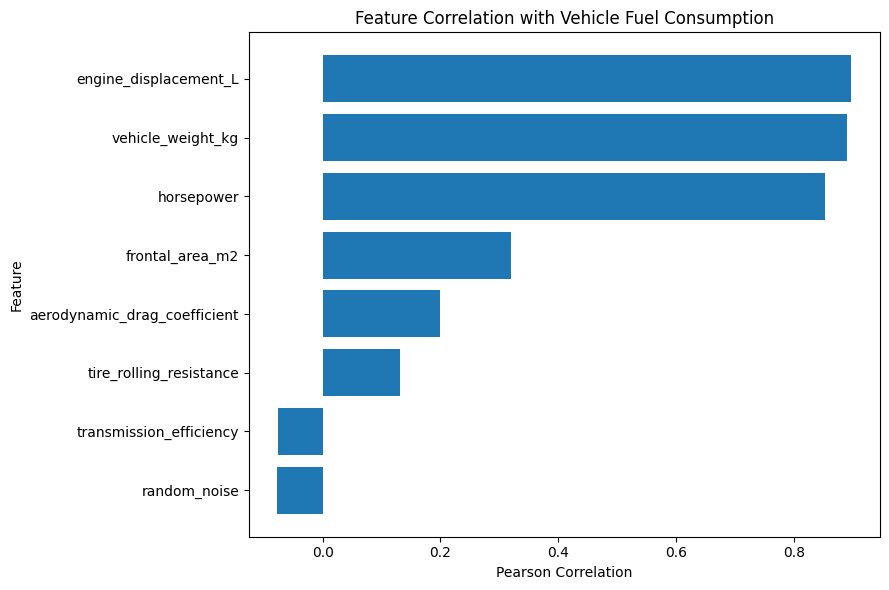

In [8]:
# ============================================================
# CELL 8 — Correlation Visualization
# ============================================================

feature_correlations = (
    correlation
    .drop(target_column)
    .sort_values()
)

plt.figure(
    figsize=(9, 6)
)

plt.barh(
    feature_correlations.index,
    feature_correlations.values
)

plt.xlabel(
    "Pearson Correlation"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Feature Correlation with Vehicle Fuel Consumption"
)

plt.tight_layout()

plt.show()

In [9]:
# ============================================================
# CELL 9 — Separate Features and Target
# ============================================================

X = auto_df.drop(
    columns=[target_column]
)

y = auto_df[target_column]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature matrix shape: (700, 8)
Target shape: (700,)

Features:
['engine_displacement_L', 'vehicle_weight_kg', 'horsepower', 'aerodynamic_drag_coefficient', 'frontal_area_m2', 'tire_rolling_resistance', 'transmission_efficiency', 'random_noise']


In [10]:
# ============================================================
# CELL 10 — Train/Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 560
Testing samples : 140


In [11]:
# ============================================================
# CELL 11 — Train Random Forest Regressor
# ============================================================

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=SEED,
    n_jobs=-1,
    max_features=1.0
)

rf.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [12]:
# ============================================================
# CELL 12 — Train Gradient Boosting Regressor
# ============================================================

gbr = GradientBoostingRegressor(
    n_estimators=250,
    learning_rate=0.04,
    max_depth=3,
    random_state=SEED
)

gbr.fit(
    X_train,
    y_train
)

print("Gradient Boosting training completed.")

Gradient Boosting training completed.


In [13]:
# ============================================================
# CELL 13 — Evaluate Regression Models
# ============================================================

models = {
    "Random Forest": rf,
    "Gradient Boosting": gbr
}

results = []

for name, model in models.items():

    predictions = model.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(
    results
)

display(
    results_df.round(4)
)

,Model,MAE,RMSE,R2
0,Random Forest,0.5873,0.7403,0.9299
1,Gradient Boosting,0.6040,0.7371,0.9306


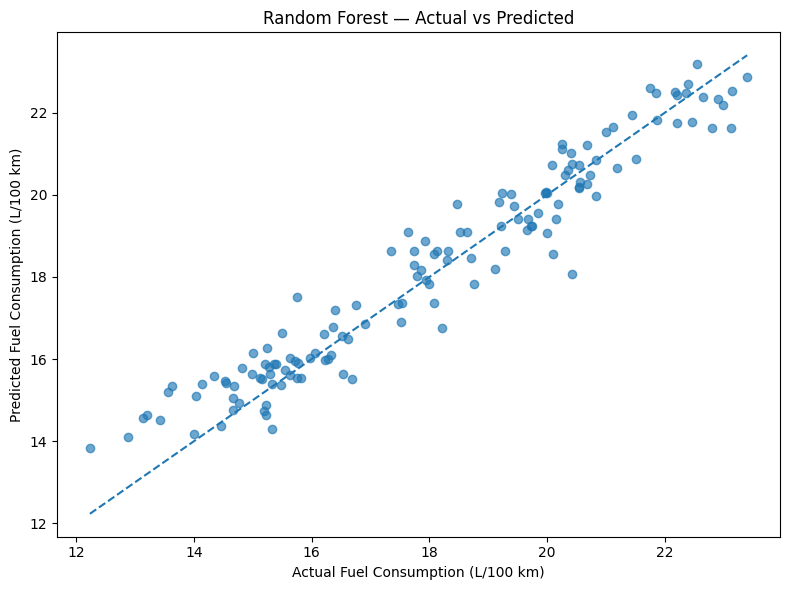

In [14]:
# ============================================================
# CELL 14 — Actual vs Predicted Fuel Consumption
# ============================================================

rf_predictions = rf.predict(
    X_test
)

plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.65
)

min_value = min(
    y_test.min(),
    rf_predictions.min()
)

max_value = max(
    y_test.max(),
    rf_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel(
    "Actual Fuel Consumption (L/100 km)"
)

plt.ylabel(
    "Predicted Fuel Consumption (L/100 km)"
)

plt.title(
    "Random Forest — Actual vs Predicted"
)

plt.tight_layout()

plt.show()

In [15]:
# ============================================================
# CELL 15 — Mean Decrease in Impurity (MDI)
# ============================================================

mdi_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(
    ascending=False
)

print(
    "Mean Decrease in Impurity (MDI):"
)

display(
    mdi_importance.to_frame(
        name="MDI Importance"
    )
)

Mean Decrease in Impurity (MDI):


,MDI Importance
engine_displacement_L,0.722068
vehicle_weight_kg,0.125569
frontal_area_m2,0.062408
aerodynamic_drag_coefficient,0.041945
tire_rolling_resistance,0.021378
horsepower,0.011800
transmission_efficiency,0.008022
random_noise,0.006812


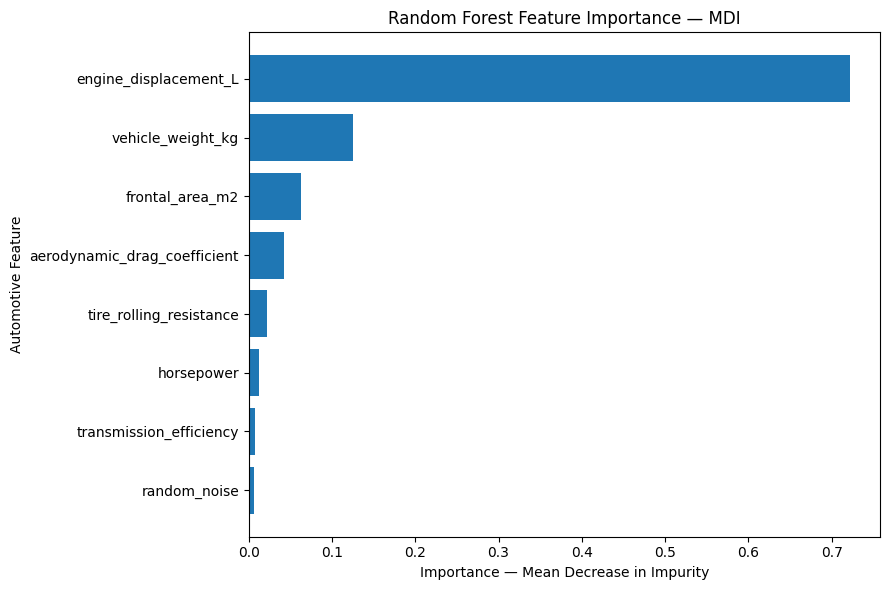

In [16]:
# ============================================================
# CELL 16 — Visualize MDI Feature Importance
# ============================================================

plt.figure(
    figsize=(9, 6)
)

mdi_sorted = mdi_importance.sort_values()

plt.barh(
    mdi_sorted.index,
    mdi_sorted.values
)

plt.xlabel(
    "Importance — Mean Decrease in Impurity"
)

plt.ylabel(
    "Automotive Feature"
)

plt.title(
    "Random Forest Feature Importance — MDI"
)

plt.tight_layout()

plt.show()

In [17]:
# ============================================================
# CELL 17 — Normalize MDI Importance
# ============================================================

mdi_normalized = (
    mdi_importance
    / mdi_importance.sum()
)

mdi_table = pd.DataFrame({
    "Feature": mdi_normalized.index,
    "MDI Importance": mdi_normalized.values
})

display(
    mdi_table.round(4)
)

,Feature,MDI Importance
0,engine_displacement_L,0.7221
1,vehicle_weight_kg,0.1256
2,frontal_area_m2,0.0624
3,aerodynamic_drag_coefficient,0.0419
4,tire_rolling_resistance,0.0214
5,horsepower,0.0118
6,transmission_efficiency,0.0080
7,random_noise,0.0068


In [18]:
# ============================================================
# CELL 18 — Permutation Feature Importance (PFI)
# ============================================================

pfi = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=SEED,
    scoring="r2",
    n_jobs=-1
)

pfi_mean = pd.Series(
    pfi.importances_mean,
    index=X.columns
)

pfi_std = pd.Series(
    pfi.importances_std,
    index=X.columns
)

pfi_table = pd.DataFrame({
    "Feature": X.columns,
    "PFI Mean": pfi_mean.values,
    "PFI Std": pfi_std.values
}).sort_values(
    "PFI Mean",
    ascending=False
)

display(
    pfi_table.round(4)
)

,Feature,PFI Mean,PFI Std
0,engine_displacement_L,0.8595,0.0917
1,vehicle_weight_kg,0.1604,0.0148
4,frontal_area_m2,0.1155,0.0115
3,aerodynamic_drag_coefficient,0.0516,0.0073
5,tire_rolling_resistance,0.0233,0.0042
2,horsepower,0.0088,0.0018
6,transmission_efficiency,0.0041,0.0013
7,random_noise,0.0015,0.0008


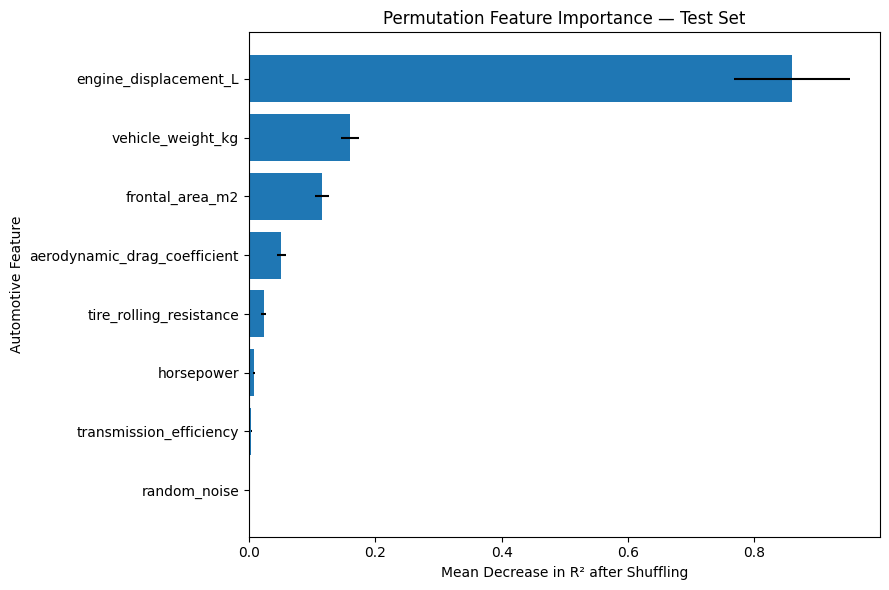

In [19]:
# ============================================================
# CELL 19 — Visualize Permutation Feature Importance
# ============================================================

pfi_sorted = pfi_table.sort_values(
    "PFI Mean"
)

plt.figure(
    figsize=(9, 6)
)

plt.barh(
    pfi_sorted["Feature"],
    pfi_sorted["PFI Mean"],
    xerr=pfi_sorted["PFI Std"]
)

plt.xlabel(
    "Mean Decrease in R² after Shuffling"
)

plt.ylabel(
    "Automotive Feature"
)

plt.title(
    "Permutation Feature Importance — Test Set"
)

plt.tight_layout()

plt.show()

In [20]:
# ============================================================
# CELL 20 — Compare MDI and PFI
# ============================================================

importance_comparison = pd.DataFrame({
    "MDI": mdi_importance,
    "Permutation Importance": pfi_mean
})

importance_comparison = (
    importance_comparison
    .sort_values(
        "MDI",
        ascending=False
    )
)

display(
    importance_comparison.round(4)
)

,MDI,Permutation Importance
engine_displacement_L,0.7221,0.8595
vehicle_weight_kg,0.1256,0.1604
frontal_area_m2,0.0624,0.1155
aerodynamic_drag_coefficient,0.0419,0.0516
tire_rolling_resistance,0.0214,0.0233
horsepower,0.0118,0.0088
transmission_efficiency,0.0080,0.0041
random_noise,0.0068,0.0015


In [21]:
# ============================================================
# CELL 21 — Mutual Information Feature Importance
# ============================================================

mi_values = mutual_info_regression(
    X_train,
    y_train,
    random_state=SEED
)

mi_importance = pd.Series(
    mi_values,
    index=X.columns
).sort_values(
    ascending=False
)

mi_table = pd.DataFrame({
    "Feature": mi_importance.index,
    "Mutual Information": mi_importance.values
})

display(
    mi_table.round(4)
)

,Feature,Mutual Information
0,engine_displacement_L,0.8062
1,vehicle_weight_kg,0.7831
2,horsepower,0.6864
3,aerodynamic_drag_coefficient,0.0905
4,tire_rolling_resistance,0.0604
5,frontal_area_m2,0.0506
6,random_noise,0.0169
7,transmission_efficiency,0.0000


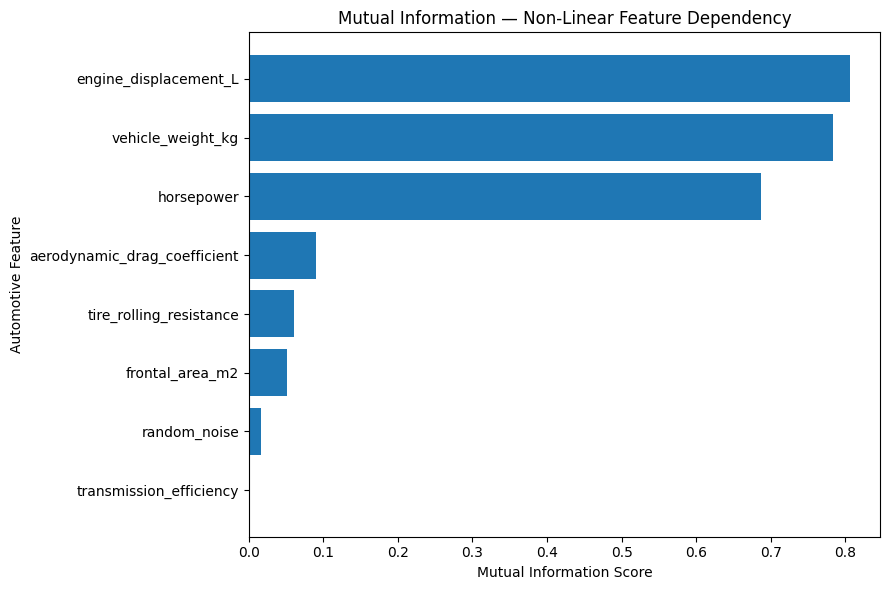

In [22]:
# ============================================================
# CELL 22 — Visualize Mutual Information
# ============================================================

mi_sorted = mi_importance.sort_values()

plt.figure(
    figsize=(9, 6)
)

plt.barh(
    mi_sorted.index,
    mi_sorted.values
)

plt.xlabel(
    "Mutual Information Score"
)

plt.ylabel(
    "Automotive Feature"
)

plt.title(
    "Mutual Information — Non-Linear Feature Dependency"
)

plt.tight_layout()

plt.show()

In [23]:
# ============================================================
# CELL 23 — Combined Feature Importance Table
# ============================================================

combined_importance = pd.DataFrame({

    "MDI":
        mdi_importance,

    "Permutation Importance":
        pfi_mean,

    "Mutual Information":
        mi_importance
})

display(
    combined_importance
    .sort_values(
        "MDI",
        ascending=False
    )
    .round(4)
)

,MDI,Permutation Importance,Mutual Information
engine_displacement_L,0.7221,0.8595,0.8062
vehicle_weight_kg,0.1256,0.1604,0.7831
frontal_area_m2,0.0624,0.1155,0.0506
aerodynamic_drag_coefficient,0.0419,0.0516,0.0905
tire_rolling_resistance,0.0214,0.0233,0.0604
horsepower,0.0118,0.0088,0.6864
transmission_efficiency,0.0080,0.0041,0.0000
random_noise,0.0068,0.0015,0.0169


In [24]:
# ============================================================
# CELL 24 — Normalize Importance Scores for Comparison
# ============================================================

comparison_normalized = pd.DataFrame({

    "MDI":
        mdi_importance / mdi_importance.sum(),

    "PFI":
        pfi_mean.clip(lower=0)
        / pfi_mean.clip(lower=0).sum(),

    "MI":
        mi_importance / mi_importance.sum()
})

display(
    comparison_normalized
    .sort_values(
        "MDI",
        ascending=False
    )
    .round(4)
)

,MDI,PFI,MI
engine_displacement_L,0.7221,0.7018,0.3232
vehicle_weight_kg,0.1256,0.1309,0.3140
frontal_area_m2,0.0624,0.0943,0.0203
aerodynamic_drag_coefficient,0.0419,0.0421,0.0363
tire_rolling_resistance,0.0214,0.0190,0.0242
horsepower,0.0118,0.0072,0.2752
transmission_efficiency,0.0080,0.0033,0.0000
random_noise,0.0068,0.0012,0.0068


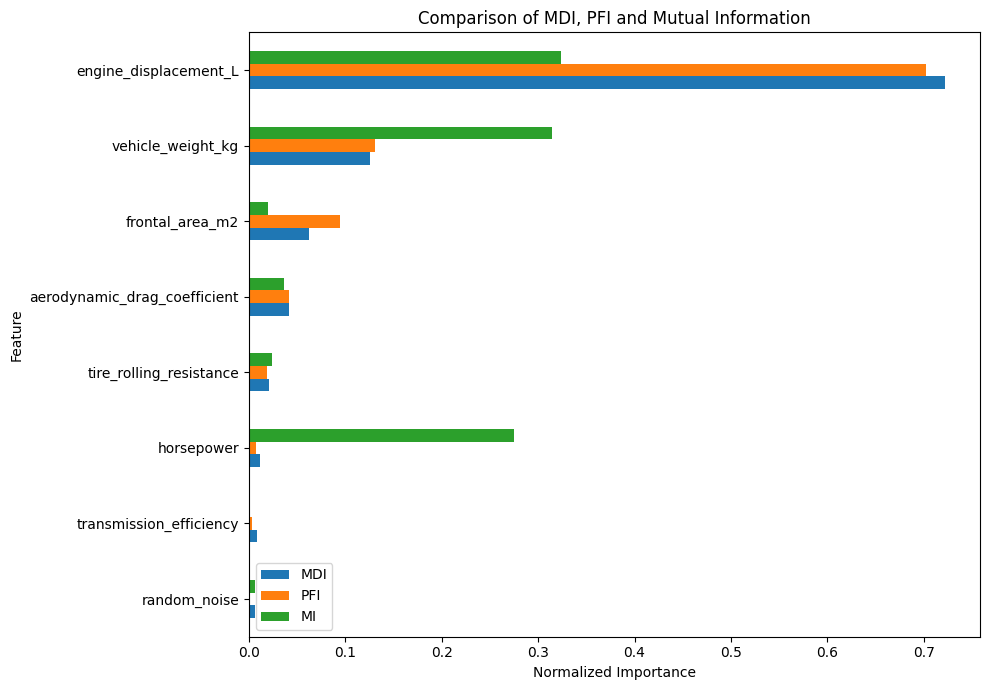

In [25]:
# ============================================================
# CELL 25 — Comparative Feature Importance Visualization
# ============================================================

plot_data = comparison_normalized.sort_values(
    "MDI"
)

ax = plot_data.plot(
    kind="barh",
    figsize=(10, 7)
)

ax.set_xlabel(
    "Normalized Importance"
)

ax.set_ylabel(
    "Feature"
)

ax.set_title(
    "Comparison of MDI, PFI and Mutual Information"
)

plt.tight_layout()

plt.show()

In [26]:
# ============================================================
# CELL 26 — Identify Important Automotive Features
# ============================================================

top_mdi = mdi_importance.head(5)

top_pfi = pfi_mean.sort_values(
    ascending=False
).head(5)

top_mi = mi_importance.head(5)

print("Top features according to MDI:")
print(top_mdi)

print("\nTop features according to PFI:")
print(top_pfi)

print("\nTop features according to Mutual Information:")
print(top_mi)

Top features according to MDI:
engine_displacement_L           0.722068
vehicle_weight_kg               0.125569
frontal_area_m2                 0.062408
aerodynamic_drag_coefficient    0.041945
tire_rolling_resistance         0.021378
dtype: float64

Top features according to PFI:
engine_displacement_L           0.859478
vehicle_weight_kg               0.160358
frontal_area_m2                 0.115549
aerodynamic_drag_coefficient    0.051596
tire_rolling_resistance         0.023301
dtype: float64

Top features according to Mutual Information:
engine_displacement_L           0.806155
vehicle_weight_kg               0.783110
horsepower                      0.686430
aerodynamic_drag_coefficient    0.090457
tire_rolling_resistance         0.060376
dtype: float64


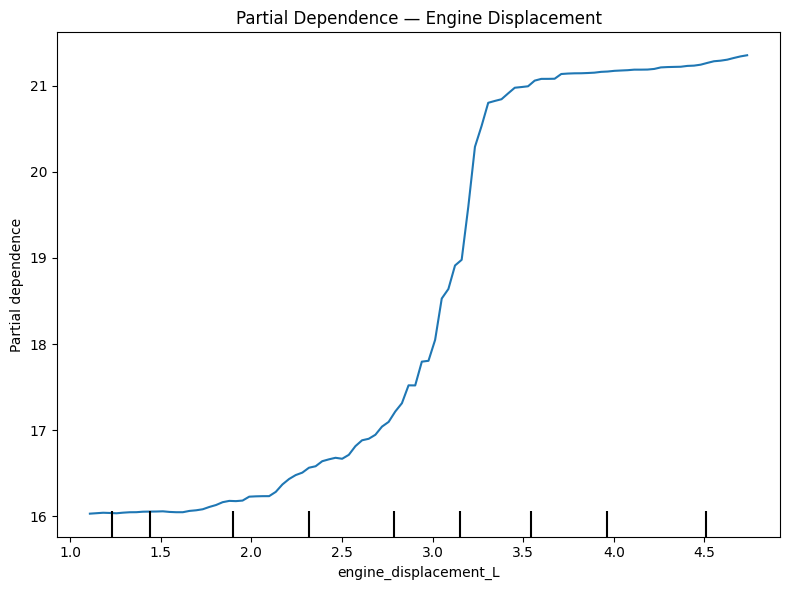

In [27]:
# ============================================================
# CELL 27 — Partial Dependence Plot: Engine Displacement
# ============================================================

feature = "engine_displacement_L"

fig, ax = plt.subplots(
    figsize=(8, 6)
)

PartialDependenceDisplay.from_estimator(
    rf,
    X_test,
    [feature],
    ax=ax
)

ax.set_title(
    "Partial Dependence — Engine Displacement"
)

plt.tight_layout()

plt.show()

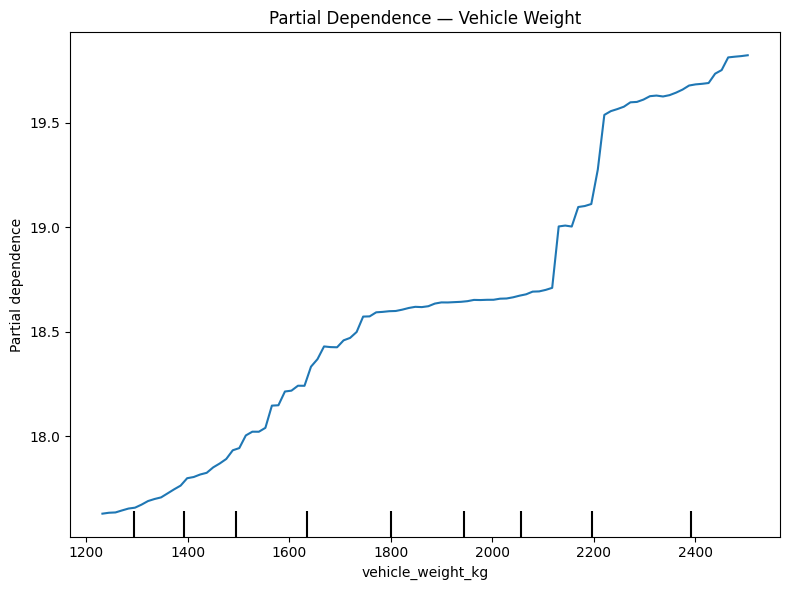

In [28]:
# ============================================================
# CELL 28 — Partial Dependence Plot: Vehicle Weight
# ============================================================

feature = "vehicle_weight_kg"

fig, ax = plt.subplots(
    figsize=(8, 6)
)

PartialDependenceDisplay.from_estimator(
    rf,
    X_test,
    [feature],
    ax=ax
)

ax.set_title(
    "Partial Dependence — Vehicle Weight"
)

plt.tight_layout()

plt.show()

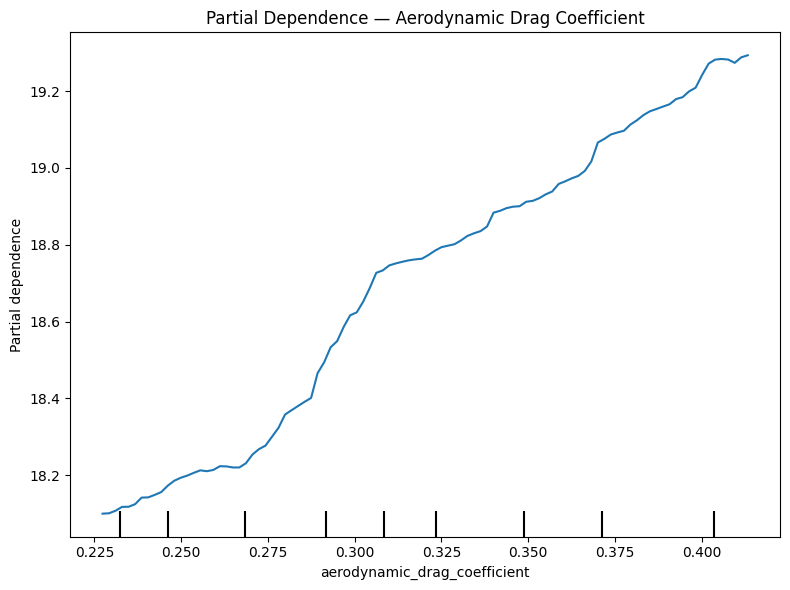

In [29]:
# ============================================================
# CELL 29 — Partial Dependence Plot: Aerodynamic Drag
# ============================================================

feature = "aerodynamic_drag_coefficient"

fig, ax = plt.subplots(
    figsize=(8, 6)
)

PartialDependenceDisplay.from_estimator(
    rf,
    X_test,
    [feature],
    ax=ax
)

ax.set_title(
    "Partial Dependence — Aerodynamic Drag Coefficient"
)

plt.tight_layout()

plt.show()

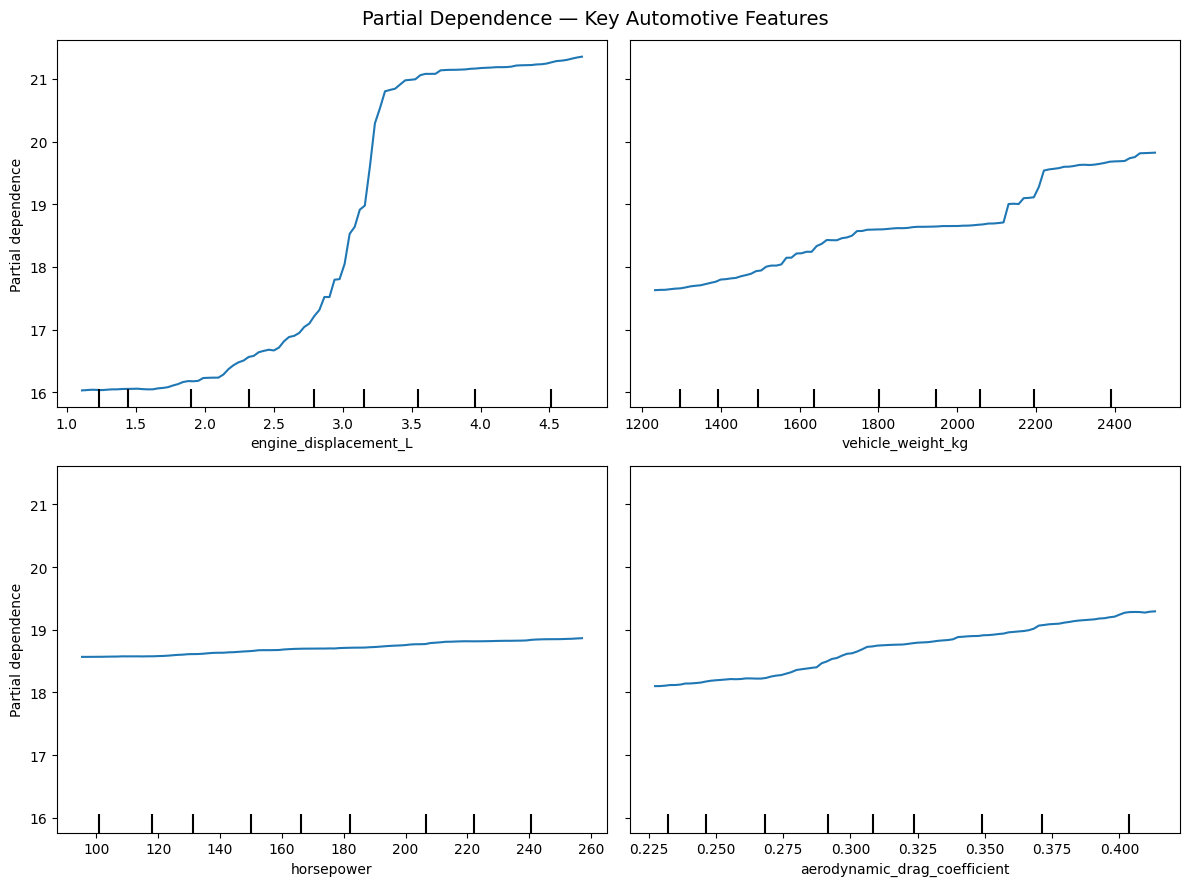

In [30]:
# ============================================================
# CELL 30 — Partial Dependence for Multiple Important Features
# ============================================================

top_features = [
    "engine_displacement_L",
    "vehicle_weight_kg",
    "horsepower",
    "aerodynamic_drag_coefficient"
]

fig, ax = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 9)
)

PartialDependenceDisplay.from_estimator(
    rf,
    X_test,
    top_features,
    ax=ax
)

plt.suptitle(
    "Partial Dependence — Key Automotive Features",
    fontsize=14
)

plt.tight_layout()

plt.show()

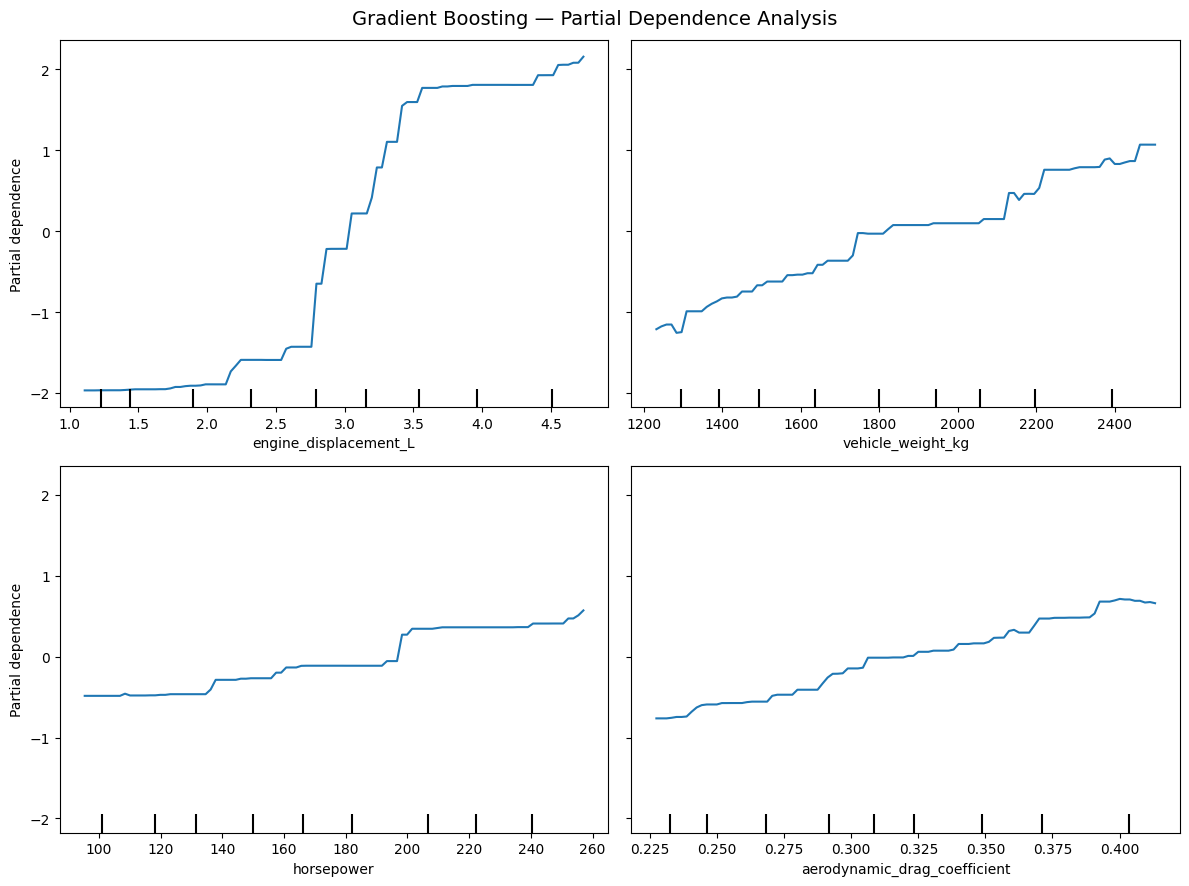

In [31]:
# ============================================================
# CELL 31 — PDP using Gradient Boosting Model
# ============================================================

fig, ax = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 9)
)

PartialDependenceDisplay.from_estimator(
    gbr,
    X_test,
    top_features,
    ax=ax
)

plt.suptitle(
    "Gradient Boosting — Partial Dependence Analysis",
    fontsize=14
)

plt.tight_layout()

plt.show()

In [32]:
# ============================================================
# CELL 32 — Noise Immunity Test
# ============================================================

noise_columns = [
    "random_noise"
]

print(
    "Noise feature statistics:"
)

display(
    auto_df[
        noise_columns
    ].describe()
)

Noise feature statistics:


,random_noise
count,700.000000
mean,-0.070379
std,0.992750
min,-3.176704
25%,-0.701599
50%,-0.018242
75%,0.645692
max,2.755218


In [33]:
# ============================================================
# CELL 33 — Correlation of Noise with Target
# ============================================================

noise_correlation = (
    auto_df[
        "random_noise"
    ].corr(
        auto_df[
            target_column
        ]
    )
)

print(
    f"Correlation between random noise "
    f"and fuel consumption: "
    f"{noise_correlation:.6f}"
)

Correlation between random noise and fuel consumption: -0.076821


In [34]:
# ============================================================
# CELL 34 — Noise Feature MDI Importance
# ============================================================

noise_mdi = mdi_importance[
    "random_noise"
]

print(
    f"Random noise MDI importance: "
    f"{noise_mdi:.6f}"
)

Random noise MDI importance: 0.006812


In [35]:
# ============================================================
# CELL 35 — Noise Feature Permutation Importance
# ============================================================

noise_pfi_mean = pfi_mean[
    "random_noise"
]

noise_pfi_std = pfi_std[
    "random_noise"
]

print(
    f"Random noise PFI mean: "
    f"{noise_pfi_mean:.6f}"
)

print(
    f"Random noise PFI std : "
    f"{noise_pfi_std:.6f}"
)

Random noise PFI mean: 0.001484
Random noise PFI std : 0.000827


In [36]:
# ============================================================
# CELL 36 — Noise Feature Mutual Information
# ============================================================

noise_mi = mi_importance[
    "random_noise"
]

print(
    f"Random noise Mutual Information: "
    f"{noise_mi:.6f}"
)

Random noise Mutual Information: 0.016891


In [37]:
# ============================================================
# CELL 37 — Noise Immunity Summary
# ============================================================

noise_summary = pd.DataFrame({

    "Method": [
        "MDI",
        "Permutation Importance",
        "Mutual Information"
    ],

    "Random Noise Score": [
        noise_mdi,
        noise_pfi_mean,
        noise_mi
    ]
})

display(
    noise_summary.round(6)
)

,Method,Random Noise Score
0,MDI,0.006812
1,Permutation Importance,0.001484
2,Mutual Information,0.016891


In [38]:
# ============================================================
# CELL 38 — Compare Noise Against Top Features
# ============================================================

comparison_features = [
    "engine_displacement_L",
    "vehicle_weight_kg",
    "horsepower",
    "aerodynamic_drag_coefficient",
    "random_noise"
]

noise_comparison = pd.DataFrame({

    "MDI":
        mdi_importance[
            comparison_features
        ],

    "PFI":
        pfi_mean[
            comparison_features
        ],

    "MI":
        mi_importance[
            comparison_features
        ]
})

display(
    noise_comparison.round(6)
)

,MDI,PFI,MI
engine_displacement_L,0.722068,0.859478,0.806155
vehicle_weight_kg,0.125569,0.160358,0.783110
horsepower,0.011800,0.008833,0.686430
aerodynamic_drag_coefficient,0.041945,0.051596,0.090457
random_noise,0.006812,0.001484,0.016891


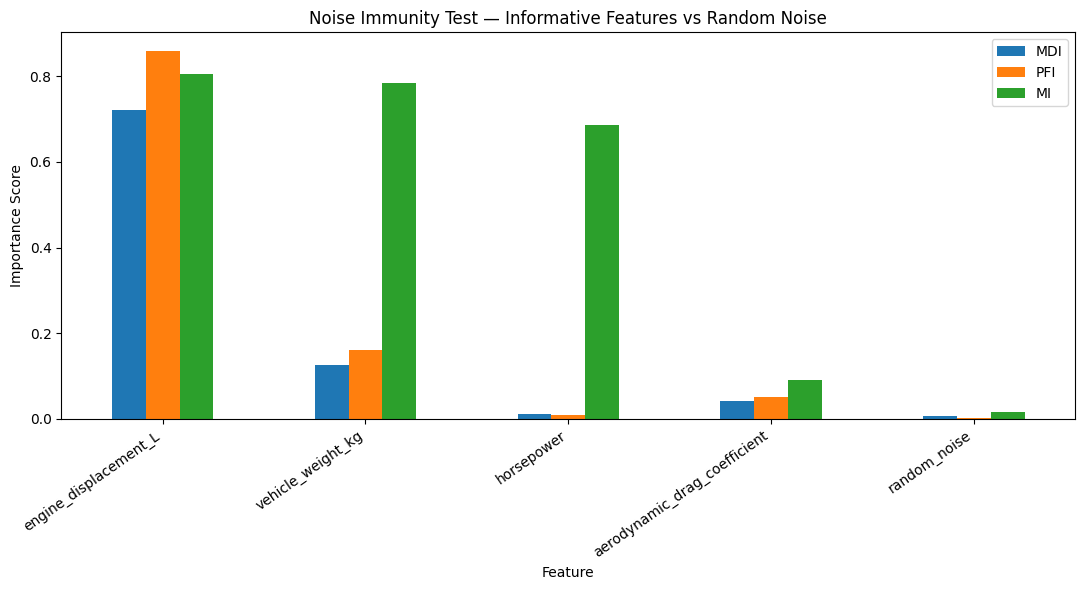

In [39]:
# ============================================================
# CELL 39 — Visualize Noise Immunity
# ============================================================

noise_plot = noise_comparison.copy()

ax = noise_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_xlabel(
    "Feature"
)

ax.set_ylabel(
    "Importance Score"
)

ax.set_title(
    "Noise Immunity Test — Informative Features vs Random Noise"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()

plt.show()

In [40]:
# ============================================================
# CELL 40 — Feature Ranking
# ============================================================

ranking_df = pd.DataFrame({

    "MDI Rank":
        mdi_importance.rank(
            ascending=False,
            method="min"
        ).astype(int),

    "PFI Rank":
        pfi_mean.rank(
            ascending=False,
            method="min"
        ).astype(int),

    "MI Rank":
        mi_importance.rank(
            ascending=False,
            method="min"
        ).astype(int)
})

ranking_df = ranking_df.sort_values(
    "MDI Rank"
)

display(
    ranking_df
)

,MDI Rank,PFI Rank,MI Rank
engine_displacement_L,1,1,1
vehicle_weight_kg,2,2,2
frontal_area_m2,3,3,6
aerodynamic_drag_coefficient,4,4,4
tire_rolling_resistance,5,5,5
horsepower,6,6,3
transmission_efficiency,7,7,8
random_noise,8,8,7


In [41]:
# ============================================================
# CELL 41 — Generate Automated Interpretation
# ============================================================

top_mdi_feature = (
    mdi_importance.idxmax()
)

top_pfi_feature = (
    pfi_mean.idxmax()
)

top_mi_feature = (
    mi_importance.idxmax()
)

print(
    "Feature with highest MDI importance:",
    top_mdi_feature
)

print(
    "Feature with highest PFI importance:",
    top_pfi_feature
)

print(
    "Feature with highest Mutual Information:",
    top_mi_feature
)

print(
    "\nRandom noise scores:"
)

print(
    "MDI:",
    round(noise_mdi, 6)
)

print(
    "PFI:",
    round(noise_pfi_mean, 6)
)

print(
    "MI :",
    round(noise_mi, 6)
)

Feature with highest MDI importance: engine_displacement_L
Feature with highest PFI importance: engine_displacement_L
Feature with highest Mutual Information: engine_displacement_L

Random noise scores:
MDI: 0.006812
PFI: 0.001484
MI : 0.016891


In [42]:
# ============================================================
# CELL 42 — Final XAI Feature Importance Table
# ============================================================

final_importance_table = pd.DataFrame({

    "MDI":
        mdi_importance,

    "Permutation Importance":
        pfi_mean,

    "Mutual Information":
        mi_importance,

    "MDI Rank":
        mdi_importance.rank(
            ascending=False,
            method="min"
        ).astype(int),

    "PFI Rank":
        pfi_mean.rank(
            ascending=False,
            method="min"
        ).astype(int),

    "MI Rank":
        mi_importance.rank(
            ascending=False,
            method="min"
        ).astype(int)
})

final_importance_table = (
    final_importance_table
    .sort_values("MDI", ascending=False)
)

display(
    final_importance_table.round(4)
)

,MDI,Permutation Importance,Mutual Information,MDI Rank,PFI Rank,MI Rank
engine_displacement_L,0.7221,0.8595,0.8062,1,1,1
vehicle_weight_kg,0.1256,0.1604,0.7831,2,2,2
frontal_area_m2,0.0624,0.1155,0.0506,3,3,6
aerodynamic_drag_coefficient,0.0419,0.0516,0.0905,4,4,4
tire_rolling_resistance,0.0214,0.0233,0.0604,5,5,5
horsepower,0.0118,0.0088,0.6864,6,6,3
transmission_efficiency,0.0080,0.0041,0.0000,7,7,8
random_noise,0.0068,0.0015,0.0169,8,8,7


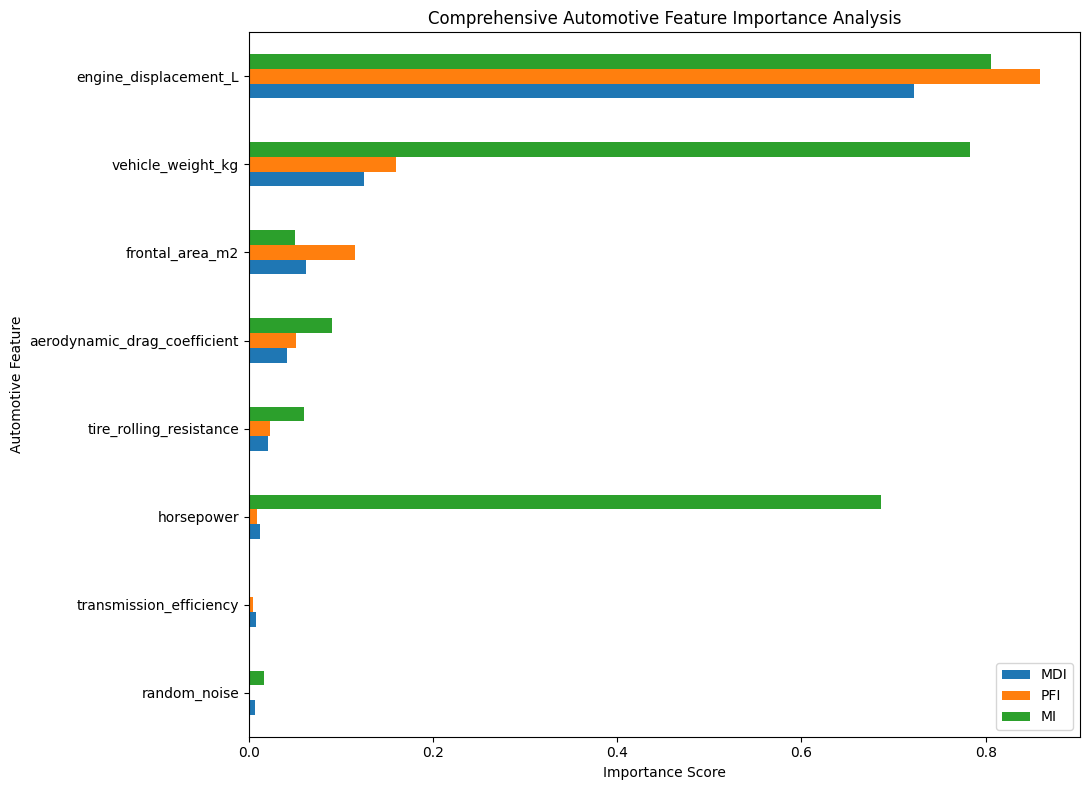

In [43]:
# ============================================================
# CELL 43 — Final Feature Importance Summary
# ============================================================

summary_features = [
    "engine_displacement_L",
    "vehicle_weight_kg",
    "horsepower",
    "aerodynamic_drag_coefficient",
    "frontal_area_m2",
    "tire_rolling_resistance",
    "transmission_efficiency",
    "random_noise"
]

summary_data = pd.DataFrame({

    "MDI":
        mdi_importance[
            summary_features
        ],

    "PFI":
        pfi_mean[
            summary_features
        ],

    "MI":
        mi_importance[
            summary_features
        ]
})

summary_data = summary_data.sort_values(
    "MDI"
)

summary_data.plot(
    kind="barh",
    figsize=(11, 8)
)

plt.xlabel(
    "Importance Score"
)

plt.ylabel(
    "Automotive Feature"
)

plt.title(
    "Comprehensive Automotive Feature Importance Analysis"
)

plt.tight_layout()

plt.show()

In [44]:
# ============================================================
# CELL 44 — Final Experiment Verification
# ============================================================

print("=" * 60)
print("ASSIGNMENT 09 — FINAL VERIFICATION")
print("=" * 60)

print(
    "\n1. Random Forest trained        :",
    hasattr(rf, "feature_importances_")
)

print(
    "2. Gradient Boosting trained    :",
    hasattr(gbr, "feature_importances_")
)

print(
    "3. MDI calculated               :",
    len(mdi_importance) == X.shape[1]
)

print(
    "4. PFI calculated               :",
    len(pfi_mean) == X.shape[1]
)

print(
    "5. Mutual Information calculated:",
    len(mi_importance) == X.shape[1]
)

print(
    "6. PDP generated                : Completed"
)

print(
    "7. Noise immunity tested        :",
    "random_noise" in X.columns
)

print(
    "\nNumber of automotive features:",
    X.shape[1]
)

print(
    "\nTarget:",
    target_column
)

print("=" * 60)

ASSIGNMENT 09 — FINAL VERIFICATION

1. Random Forest trained        : True
2. Gradient Boosting trained    : True
3. MDI calculated               : True
4. PFI calculated               : True
5. Mutual Information calculated: True
6. PDP generated                : Completed
7. Noise immunity tested        : True

Number of automotive features: 8

Target: fuel_consumption_L_per_100km


In [45]:
# ============================================================
# CELL 45 — Final Numerical Results
# ============================================================

print("MODEL PERFORMANCE")
print("-" * 50)

display(
    results_df.round(4)
)

print("\nTOP FEATURES — MDI")
print("-" * 50)

display(
    mdi_importance.head(5).round(4)
)

print("\nTOP FEATURES — PERMUTATION IMPORTANCE")
print("-" * 50)

display(
    pfi_mean.sort_values(
        ascending=False
    ).head(5).round(4)
)

print("\nTOP FEATURES — MUTUAL INFORMATION")
print("-" * 50)

display(
    mi_importance.head(5).round(4)
)

print("\nRANDOM NOISE FEATURE")
print("-" * 50)

print(
    f"MDI: {noise_mdi:.6f}"
)

print(
    f"PFI: {noise_pfi_mean:.6f}"
)

print(
    f"MI : {noise_mi:.6f}"
)

MODEL PERFORMANCE
--------------------------------------------------


,Model,MAE,RMSE,R2
0,Random Forest,0.5873,0.7403,0.9299
1,Gradient Boosting,0.6040,0.7371,0.9306



TOP FEATURES — MDI
--------------------------------------------------


,0
engine_displacement_L,0.7221
vehicle_weight_kg,0.1256
frontal_area_m2,0.0624
aerodynamic_drag_coefficient,0.0419
tire_rolling_resistance,0.0214



TOP FEATURES — PERMUTATION IMPORTANCE
--------------------------------------------------


,0
engine_displacement_L,0.8595
vehicle_weight_kg,0.1604
frontal_area_m2,0.1155
aerodynamic_drag_coefficient,0.0516
tire_rolling_resistance,0.0233



TOP FEATURES — MUTUAL INFORMATION
--------------------------------------------------


,0
engine_displacement_L,0.8062
vehicle_weight_kg,0.7831
horsepower,0.6864
aerodynamic_drag_coefficient,0.0905
tire_rolling_resistance,0.0604



RANDOM NOISE FEATURE
--------------------------------------------------
MDI: 0.006812
PFI: 0.001484
MI : 0.016891


# Conclusion

The Feature Importance Visualization experiment was successfully completed using tree-based regression models and Explainable AI techniques.

The experiment demonstrated:

- **Mean Decrease in Impurity (MDI)** for measuring impurity reduction contributed by each feature in a Random Forest.
- **Permutation Feature Importance (PFI)** for measuring the reduction in test-set model performance when individual features are shuffled.
- **Mutual Information (MI)** for identifying both linear and non-linear statistical dependencies between automotive attributes and fuel consumption.
- **Partial Dependence Plots (PDP)** for visualizing how changes in important physical vehicle attributes affect the model's predicted fuel consumption.
- **Noise Immunity Testing** to verify that an intentionally generated random feature does not provide meaningful predictive information.

The analysis provides an interpretable view of how physical automotive characteristics such as engine displacement, vehicle weight, horsepower, aerodynamic drag, rolling resistance, and transmission efficiency contribute to fuel-consumption predictions.

The comparison of multiple feature-importance techniques demonstrates that model interpretability should not depend on a single importance measure. Combining MDI, PFI, MI, and PDP provides a more comprehensive understanding of the relationship between automotive engineering variables and machine-learning predictions.

Thus, the experiment demonstrates the practical role of **Explainable AI (XAI)** in automotive powertrain efficiency analysis and transparent machine-learning model interpretation.